In [1]:
import pandas as pd
import seaborn as sns 
from matplotlib import pyplot as plt
import numpy as np

df = pd.read_csv("term_life.csv")

In [2]:
df = df.dropna(subset=['Smoker_Status', 'BMI'])
df['Policy_Year'] = 2025 - df['Issue_Year']

# Remove rows with data issues
df_clean = df[
    (df['Issue_Year'] != 2099) &    # Bad issue year
    (df['Face_Amount'] >= 0) &      # Negative face amount
    (df['Annual_Premium'] >= 0) &   # Negative premium
    (df['Issued_Age'] > 0) &        # Zero issued age
    (df['BMI'] >= 10)               # Unrealistic BMI
]

In [3]:
df_clean

,Policy_ID,Issue_Year,Term_Length,Birth_Year,Gender,Smoker_Status,Face_Amount,Annual_Premium,Post_Term_Premium,Issued_Age,...,Policy_Status,Lapse_Year,Death_Year,Renewed,BMI,ZIP_Code,Number_of_Beneficiaries,Mortality_Rate,Lapse_Rate,Policy_Year
0,POL100000,2006,20.0,1958,F,Non-Smoker,304000,130.72,NaN,48,...,Active,NaN,NaN,No,20.4,77005,3,0.001100,0.04,19
1,POL100001,2007,20.0,1944,M,Smoker,252000,146.16,NaN,63,...,Active,NaN,NaN,No,23.9,60614,3,0.010700,0.04,18
3,POL100003,2006,20.0,1943,M,Non-Smoker,197000,114.26,NaN,63,...,Death,NaN,2016.0,No,25.6,2139,2,0.005685,0.04,19
4,POL100004,2009,20.0,1954,F,Non-Smoker,324000,162.00,NaN,55,...,Active,NaN,NaN,No,23.9,77005,2,0.001800,0.04,16
5,POL100005,2008,20.0,1960,F,Smoker,308000,132.44,NaN,48,...,Active,NaN,NaN,No,26.5,90210,3,0.002550,0.04,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,POL100995,2003,20.0,1945,F,Non-Smoker,212000,112.36,NaN,58,...,Lapsed,2023.0,NaN,No,26.4,90210,4,0.002200,0.07,22
996,POL100996,2009,20.0,1956,M,Non-Smoker,396000,190.08,NaN,53,...,Active,NaN,NaN,No,25.7,90210,2,0.002500,0.04,16
997,POL100997,2009,20.0,1988,F,Non-Smoker,234000,58.50,NaN,21,...,Active,NaN,NaN,No,18.8,77005,3,0.000300,0.04,16
998,POL100998,2002,20.0,1933,M,Non-Smoker,37000,23.68,NaN,69,...,Lapsed,2022.0,NaN,No,26.1,60614,1,0.007900,0.05,23


In [5]:
lapse_by_year = df_clean.groupby('Policy_Year').apply(
    lambda x: (x['Policy_Status'] == 'Lapsed').sum() / len(x)
).rename('Actual_Lapse_Rate')

# Merge back
df_clean = df_clean.merge(lapse_by_year, on='Policy_Year')

df_clean

,Policy_ID,Issue_Year,Term_Length,Birth_Year,Gender,Smoker_Status,Face_Amount,Annual_Premium,Post_Term_Premium,Issued_Age,...,Death_Year,Renewed,BMI,ZIP_Code,Number_of_Beneficiaries,Mortality_Rate,Lapse_Rate,Policy_Year,Actual_Lapse_Rate_x,Actual_Lapse_Rate_y
0,POL100000,2006,20.0,1958,F,Non-Smoker,304000,130.72,NaN,48,...,NaN,No,20.4,77005,3,0.001100,0.04,19,0.011628,0.011628
1,POL100003,2006,20.0,1943,M,Non-Smoker,197000,114.26,NaN,63,...,2016.0,No,25.6,2139,2,0.005685,0.04,19,0.011628,0.011628
2,POL100012,2006,20.0,1976,M,Non-Smoker,118000,29.50,NaN,30,...,NaN,No,21.3,90210,3,0.000600,0.04,19,0.011628,0.011628
3,POL100024,2006,20.0,1983,F,Smoker,211000,52.75,NaN,23,...,NaN,No,23.4,85001,4,0.000729,0.04,19,0.011628,0.011628
4,POL100026,2006,20.0,1982,F,Non-Smoker,117000,29.25,NaN,24,...,NaN,No,29.1,33101,1,0.000343,0.04,19,0.011628,0.011628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,POL100913,2005,20.0,1967,M,Non-Smoker,259000,85.47,NaN,38,...,NaN,No,27.7,44101,2,0.001000,0.45,20,0.987805,0.987805
886,POL100933,2005,20.0,1983,F,Non-Smoker,513000,128.25,NaN,22,...,NaN,No,21.8,98101,3,0.000300,0.45,20,0.987805,0.987805
887,POL100966,2005,20.0,1958,M,Non-Smoker,1000,0.42,NaN,47,...,NaN,No,23.0,85001,2,0.001800,0.45,20,0.987805,0.987805
888,POL100969,2005,20.0,1969,F,Non-Smoker,64000,19.84,NaN,36,...,NaN,No,26.6,2139,3,0.000600,0.45,20,0.987805,0.987805


In [9]:
df_below20 = df_clean[df_clean['Policy_Year']<20].copy()
df_below20['Lapsed'] = (df_below20['Policy_Status'] == 'Lapsed').astype(int)
df_below20.columns

Index(['Policy_ID', 'Issue_Year', 'Term_Length', 'Birth_Year', 'Gender',
       'Smoker_Status', 'Face_Amount', 'Annual_Premium', 'Post_Term_Premium',
       'Issued_Age', 'Policy_Agent_ID', 'Payment_Method',
       'Policy_Anniversary_Month', 'Policy_Status', 'Lapse_Year', 'Death_Year',
       'Renewed', 'BMI', 'ZIP_Code', 'Number_of_Beneficiaries',
       'Mortality_Rate', 'Lapse_Rate', 'Policy_Year', 'Actual_Lapse_Rate_x',
       'Actual_Lapse_Rate_y', 'Lapsed'],
      dtype='object')

In [24]:
from scipy.stats import chi2_contingency
#chi-square test for categorical variables

def chi_square_test(df, col):
    #create a frequency table by column
    contingency = pd.crosstab(df[col], df['Lapsed']) 
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    return pd.Series({'chi2': chi2, 'p_value': p_value, 'dof': dof})

categorical_cols = ['Gender', 'Smoker_Status', 'Payment_Method', 'Number_of_Beneficiaries']
results = pd.DataFrame([chi_square_test(df_below20, col) for col in categorical_cols],
                        index=categorical_cols)
print(results.sort_values('p_value'))

                             chi2   p_value  dof
Smoker_Status            4.338513  0.037259  1.0
Payment_Method           4.281325  0.232645  3.0
Number_of_Beneficiaries  2.022413  0.731636  4.0
Gender                   0.000000  1.000000  1.0


In [28]:
from scipy.stats import pointbiserialr

continuous_cols = ['BMI', 'Issued_Age', 'Face_Amount', 'Annual_Premium']

results = []
for col in continuous_cols:
    corr, p_value = pointbiserialr(df_below20[col].dropna(), 
                                    df_below20.loc[df_below20[col].notna(), 'Lapsed'])
    results.append({'Feature': col, 'Correlation': corr, 'p_value': p_value})

print(pd.DataFrame(results).sort_values('p_value'))

          Feature  Correlation   p_value
2     Face_Amount     0.033081  0.522492
0             BMI    -0.029208  0.572349
3  Annual_Premium     0.016036  0.756615
1      Issued_Age     0.006336  0.902539


In [32]:
import statsmodels.formula.api as smf
from scipy.stats import chi2

def likelihood_ratio_test(df, test_var, is_categorical=True):
    
    var_term = f'C({test_var})' if is_categorical else test_var
    full_formula = 'Lapsed ~ C(Policy_Year)' + ' + ' + var_term

    base = smf.logit('Lapsed ~ C(Policy_Year)', data=df).fit(disp=False)
    full = smf.logit(full_formula, data=df).fit(disp=False)

    lr_stat = 2 * (full.llf - base.llf)
    dof = full.df_model - base.df_model
    p_value = chi2.sf(lr_stat, df=dof)
    
    return {
        'Variable': test_var,
        'LR_Statistic': lr_stat,
        'p_value': p_value,
        'AIC_base': base.aic,
        'AIC_full': full.aic,
        'AIC_improvement': base.aic - full.aic  # positive = better model
    }

In [34]:
tests = [
    likelihood_ratio_test(df_below20, 'Smoker_Status',          is_categorical=True),
    likelihood_ratio_test(df_below20, 'Gender',                  is_categorical=True),
    likelihood_ratio_test(df_below20, 'Payment_Method',          is_categorical=True),
    likelihood_ratio_test(df_below20, 'Number_of_Beneficiaries', is_categorical=True),
    likelihood_ratio_test(df_below20, 'BMI',                     is_categorical=False),
    likelihood_ratio_test(df_below20, 'Face_Amount',             is_categorical=False),
    likelihood_ratio_test(df_below20, 'Annual_Premium',          is_categorical=False),
]

results_df = pd.DataFrame(tests)
print(results_df)

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

                  Variable  LR_Statistic   p_value  AIC_base   AIC_full  \
0            Smoker_Status      7.633975  0.005728  42.48854  36.854566   
1                   Gender      0.246366  0.619645  42.48854  44.242174   
2           Payment_Method      4.945113  0.175861  42.48854  43.543427   
3  Number_of_Beneficiaries      2.758394  0.599036  42.48854  47.730146   
4                      BMI      0.341041  0.559229  42.48854  44.147499   
5              Face_Amount      0.432246  0.510889  42.48854  44.056294   
6           Annual_Premium      0.101720  0.749775  42.48854  44.386820   

   AIC_improvement  
0         5.633975  
1        -1.753634  
2        -1.054887  
3        -5.241606  
4        -1.658959  
5        -1.567754  
6        -1.898280  


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay, classification_report, roc_auc_score

categorical_cols = ['Smoker_Status', 'Payment_Method']
continuous_cols  = ['Policy_Year', 'Face_Amount', 'BMI']
X = df_below20[categorical_cols + continuous_cols].copy()
y = df_below20['Lapsed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [46]:
X_train_cat = pd.get_dummies(X_train[categorical_cols], drop_first=True)
X_test_cat  = pd.get_dummies(X_test[categorical_cols],  drop_first=True)

#Scale continuous values
scaler = StandardScaler()
scaler.fit(X_train[continuous_cols])

X_train_num = pd.DataFrame(scaler.transform(X_train[continuous_cols]),
                            columns=continuous_cols, index=X_train.index)
X_test_num  = pd.DataFrame(scaler.transform(X_test[continuous_cols]),
                            columns=continuous_cols, index=X_test.index)

# Combine
X_train_final = pd.concat([X_train_cat, X_train_num], axis=1)
X_test_final  = pd.concat([X_test_cat,  X_test_num],  axis=1)

In [47]:
X_train_final

,Smoker_Status_Smoker,Payment_Method_Check,Payment_Method_Credit Card,Payment_Method_Wire,Policy_Year,Face_Amount,BMI
354,True,False,False,True,-1.540635,2.719658,1.029305
99,False,False,False,True,0.609088,0.890832,-0.883324
6,True,False,False,False,1.325663,0.870735,-0.392906
187,False,False,True,False,-0.824061,1.845439,-0.638115
353,True,False,True,False,-1.540635,-1.420321,0.808617
...,...,...,...,...,...,...,...
14,False,False,False,False,1.325663,-0.455666,-1.251137
61,False,False,False,True,1.325663,0.127147,-0.638115
185,False,True,False,False,-0.824061,-0.556151,0.563408
82,True,False,False,False,1.325663,-0.556151,1.593285


In [48]:
#training model
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=43)
lr.fit(X_train_final, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=43)

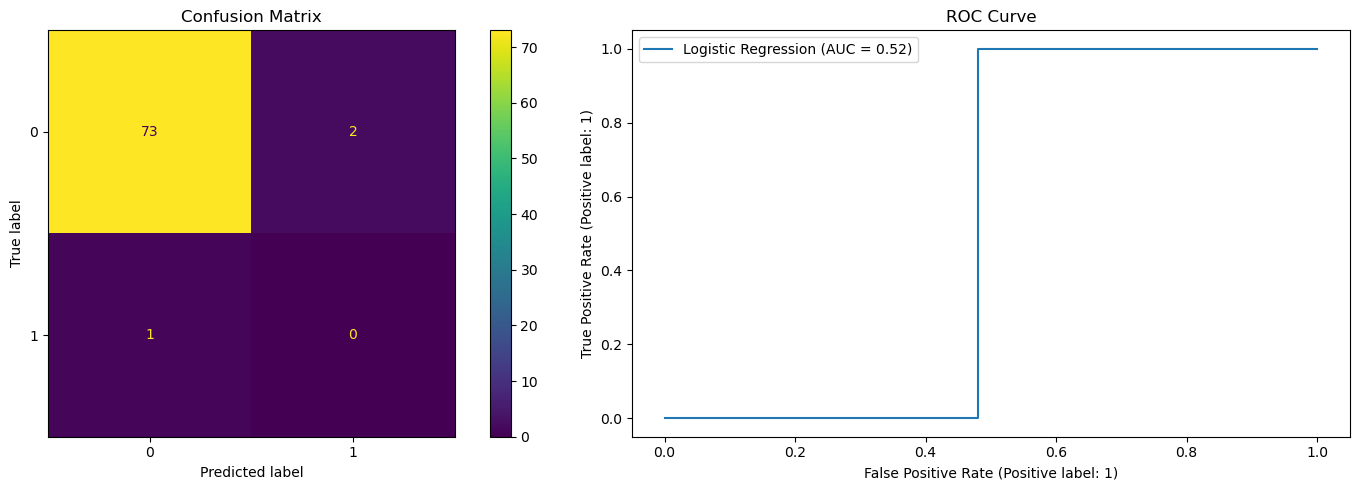

In [49]:
from sklearn.metrics import ( 
    roc_auc_score, 
    RocCurveDisplay,
    confusion_matrix,
    ConfusionMatrixDisplay)

y_pred  = lr.predict(X_test_final)
y_proba = lr.predict_proba(X_test_final)[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='Logistic Regression')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()